In [ ]:
#menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 10/data"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Latihan 1

In [ ]:
# Bikin Dataset nya
data = {
    "Temperatur": [10, 25, 15, 20, 18, 20, 22, 24],
    "Angin":      [0,  0,  5,  3,  7, 10,  5,  6],
    "Kelas":      ["Dingin","Panas","Dingin","Panas","Dingin","Dingin","Panas","Panas"]
}

df_train = pd.DataFrame(data)
df_train

,Temperatur,Angin,Kelas
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [ ]:
# Mesahkan fitur (X) dan target (y)
X = df_train[["Temperatur", "Angin"]]
y = df_train["Kelas"]

display(X)
display(y)

,Temperatur,Angin
0,10,0
1,25,0
2,15,5
3,20,3
4,18,7
5,20,10
6,22,5
7,24,6


,Kelas
0,Dingin
1,Panas
2,Dingin
3,Panas
4,Dingin
5,Dingin
6,Panas
7,Panas


In [ ]:
# Normalisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-2.00956415, -1.40556386],
       [ 1.24918853, -1.40556386],
       [-0.92331326,  0.15617376],
       [ 0.16293763, -0.46852129],
       [-0.27156272,  0.78086881],
       [ 0.16293763,  1.71791138],
       [ 0.59743799,  0.15617376],
       [ 1.03193835,  0.46852129]])

In [ ]:
# Cari nilai K terbaik
loo = LeaveOneOut()

k_list = [1,2,3,4,5,6,7]
akurasi = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=loo)
    akurasi.append(score.mean())

for k, acc in zip(k_list, akurasi):
    print(f"k={k} -> akurasi={acc:.2f}")

best_k = k_list[np.argmax(akurasi)]
print("\n✅ K terbaik =", best_k)

k=1 -> akurasi=1.00
k=2 -> akurasi=0.88
k=3 -> akurasi=0.75
k=4 -> akurasi=0.62
k=5 -> akurasi=0.50
k=6 -> akurasi=0.12
k=7 -> akurasi=0.00

✅ K terbaik = 1


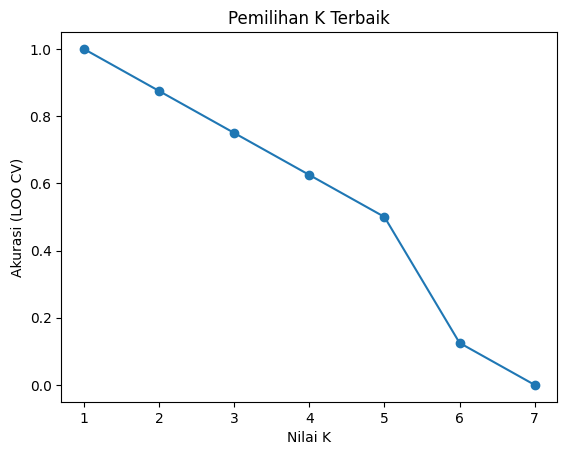

In [ ]:
plt.figure()
plt.plot(k_list, akurasi, marker="o")
plt.xticks(k_list)
plt.xlabel("Nilai K")
plt.ylabel("Akurasi (LOO CV)")
plt.title("Pemilihan K Terbaik")
plt.show()

In [ ]:
# Train model final dengan K terbaik
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_scaled, y)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
# Prediksi data test
data_test = pd.DataFrame({"Temperatur":[16], "Angin":[3]})

data_test_scaled = scaler.transform(data_test)
prediksi = model.predict(data_test_scaled)

print("Data test:", data_test.values)
print("✅ Prediksi persepsi Marry =", prediksi[0])

Data test: [[16  3]]
✅ Prediksi persepsi Marry = Dingin


In [ ]:
# Latihan 2

In [ ]:
# Import library
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [ ]:
# Memasukkan data dari tabel
aktual = ["Lulus","Lulus","Lulus","Lulus","Lulus",
          "Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]

prediksi = ["Lulus","Lulus","Lulus","Tidak Lulus","Tidak Lulus",
            "Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus","Tidak Lulus"]

df = pd.DataFrame({
    "Aktual": aktual,
    "Prediksi": prediksi
})

df

,Aktual,Prediksi
0,Lulus,Lulus
1,Lulus,Lulus
2,Lulus,Lulus
3,Lulus,Tidak Lulus
4,Lulus,Tidak Lulus
5,Tidak Lulus,Lulus
6,Tidak Lulus,Tidak Lulus
7,Tidak Lulus,Tidak Lulus
8,Tidak Lulus,Tidak Lulus
9,Tidak Lulus,Tidak Lulus


In [ ]:
# Buat Confusion Matrix
cm = confusion_matrix(aktual, prediksi, labels=["Lulus","Tidak Lulus"])
cm_df = pd.DataFrame(cm,
                     index=["Aktual Lulus","Aktual Tidak Lulus"],
                     columns=["Prediksi Lulus","Prediksi Tidak Lulus"])

cm_df

,Prediksi Lulus,Prediksi Tidak Lulus
Aktual Lulus,3,2
Aktual Tidak Lulus,1,4


In [ ]:
TP = cm[0,0]
FN = cm[0,1]
FP = cm[1,0]
TN = cm[1,1]

print("TP =", TP)
print("FN =", FN)
print("FP =", FP)
print("TN =", TN)

TP = 3
FN = 2
FP = 1
TN = 4


In [ ]:
# Hitung Accuracy, Precision, Recall
accuracy  = accuracy_score(aktual, prediksi)
precision = precision_score(aktual, prediksi, pos_label="Lulus")
recall    = recall_score(aktual, prediksi, pos_label="Lulus")

print("Accuracy  =", accuracy,  "->", accuracy*100,  "%")
print("Precision =", precision, "->", precision*100, "%")
print("Recall    =", recall,    "->", recall*100,    "%")

Accuracy  = 0.7 -> 70.0 %
Precision = 0.75 -> 75.0 %
Recall    = 0.6 -> 60.0 %


In [ ]:
# Tampilkan classification report
from sklearn.metrics import classification_report

print(classification_report(aktual, prediksi, target_names=["Lulus","Tidak Lulus"]))

              precision    recall  f1-score   support

       Lulus       0.75      0.60      0.67         5
 Tidak Lulus       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



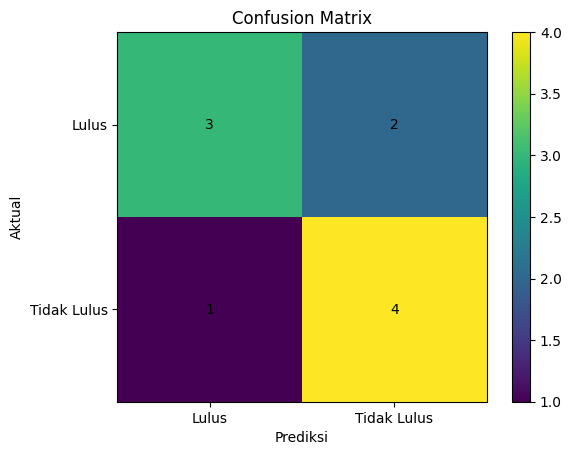

In [ ]:
# Visualisasi confusion matrix
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["Lulus","Tidak Lulus"])
plt.yticks([0,1], ["Lulus","Tidak Lulus"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")

# kasih angka di kotak
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [ ]:
# Latihan 3

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Kuliah/Semester 7/Machine Learning/Praktikum/praktikum mandiri/praktikum mandiri 10/data/weather_classification_data.csv")
df

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
...,...,...,...,...,...,...,...,...,...,...,...
13195,10.0,74,14.5,71.0,overcast,1003.15,1,Summer,1.0,mountain,Rainy
13196,-1.0,76,3.5,23.0,cloudy,1067.23,1,Winter,6.0,coastal,Snowy
13197,30.0,77,5.5,28.0,overcast,1012.69,3,Autumn,9.0,coastal,Cloudy
13198,3.0,76,10.0,94.0,overcast,984.27,0,Winter,2.0,inland,Snowy


In [ ]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Cek struktur & missing value
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


In [ ]:
df = df.dropna()

In [ ]:
# Pisahkan fitur (X) dan label (y)
X = df.drop(columns=["Weather Type"])
y = df["Weather Type"]

print(X.columns)
y.value_counts()

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location'],
      dtype='object')


,count
Weather Type,
Rainy,3300
Cloudy,3300
Sunny,3300
Snowy,3300


In [ ]:
# Tentukan kolom numerik vs kategorikal
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerik:", list(num_cols))
print("Kategorikal:", list(cat_cols))

Numerik: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
Kategorikal: ['Cloud Cover', 'Season', 'Location']


In [ ]:
# Preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [ ]:
# Split data train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Hyperparameter tuning
knn = KNeighborsClassifier()

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("knn", knn)
])

param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Best CV Score: 0.8979166666666666


In [ ]:
# Latih model terbaik & prediksi
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

In [ ]:
#Evaluasi
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8958333333333334

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.83      0.90      0.86       660
       Rainy       0.88      0.89      0.88       660
       Snowy       0.93      0.91      0.92       660
       Sunny       0.95      0.88      0.92       660

    accuracy                           0.90      2640
   macro avg       0.90      0.90      0.90      2640
weighted avg       0.90      0.90      0.90      2640



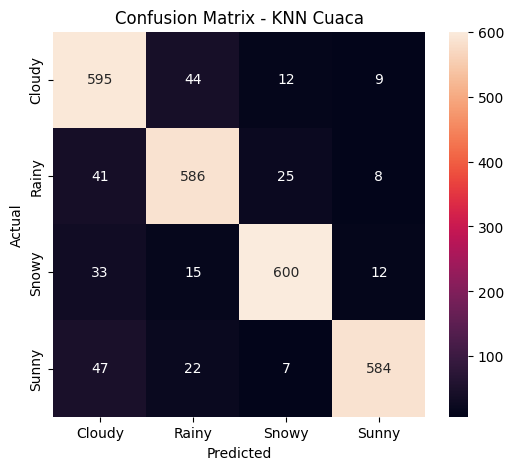

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN Cuaca")
plt.show()

In [ ]:
# Cross-validation
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)
print("CV mean:", cv_scores.mean())
print("CV std:", cv_scores.std())

CV mean: 0.8979166666666666
CV std: 0.004386831371932001
